# Pokemon Ranking Data

In [2]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## Pandas Practice

In [3]:
# open excel
df = pd.read_excel(r'C:\Users\isaac\Downloads\rated_pokemon.xlsx')
# show data frame
df.head()

,#,Name,Stage,Generation,Type1,Type2,Legendary/Mythical,Final Score
0,1.0,Bulbasaur,0.0,1.0,Grass,Poison,N,4.5
1,2.0,Ivysaur,1.0,1.0,Grass,Poison,N,4.3
2,3.0,Venusaur,2.0,1.0,Grass,Poison,N,2.4
3,4.0,Charmander,0.0,1.0,Fire,NaN,N,4
4,5.0,Charmeleon,1.0,1.0,Fire,NaN,N,2.6


In [4]:
# get info on df
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1027 entries, 0 to 1026
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   #                   1027 non-null   float64
 1   Name                1027 non-null   str    
 2   Stage               1026 non-null   float64
 3   Generation          1026 non-null   float64
 4   Type1               1025 non-null   str    
 5   Type2               527 non-null    object 
 6   Legendary/Mythical  1026 non-null   str    
 7   Final Score         1027 non-null   object 
dtypes: float64(3), object(2), str(3)
memory usage: 64.3+ KB


In [5]:
# drop column
df = df.drop(columns=['#'])
# set nas to none
df['Type2'] = df['Type2'].fillna('None')

In [6]:
# view nas and drop them
df[df.isna().any(axis=1)]
df = df.dropna()
df.info()

<class 'pandas.DataFrame'>
Index: 1025 entries, 0 to 1026
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                1025 non-null   str    
 1   Stage               1025 non-null   float64
 2   Generation          1025 non-null   float64
 3   Type1               1025 non-null   str    
 4   Type2               1025 non-null   object 
 5   Legendary/Mythical  1025 non-null   str    
 6   Final Score         1025 non-null   object 
dtypes: float64(2), object(2), str(3)
memory usage: 64.1+ KB


In [7]:
# cast final score as float
df['Final Score'] = df['Final Score'].astype(float)
# describe data
df.describe()

,Stage,Generation,Final Score
count,1025.000000,1025.000000,1025.000000
mean,0.579512,4.741463,3.126176
std,0.688756,2.633633,1.016319
min,0.000000,1.000000,0.800000
25%,0.000000,3.000000,2.500000
50%,0.000000,5.000000,3.250000
75%,1.000000,7.000000,3.880000
max,2.000000,9.000000,5.000000


In [8]:
# set all scores less than 1 equal to 1
df.loc[df['Final Score'] < 1, 'Final Score'] = 1
df.loc[df['Legendary/Mythical'] == 'N', 'Legendary/Mythical'] = '0'
df.loc[df['Legendary/Mythical'] == 'Y', 'Legendary/Mythical'] = '1'
df['Legendary/Mythical'] = df['Legendary/Mythical'].astype(float)

In [9]:
# get value counts
df['Type1'].value_counts()

Type1
Water       134
Normal      118
Grass       103
Bug          83
Fire         66
Psychic      60
Electric     59
Rock         58
Dark         45
Poison       42
Ground       40
Fighting     40
Dragon       37
Steel        36
Ghost        35
Ice          31
Fairy        29
Flying        9
Name: count, dtype: int64

In [10]:
df['Type2'].nunique()

19

In [11]:
df.head()

,Name,Stage,Generation,Type1,Type2,Legendary/Mythical,Final Score
0,Bulbasaur,0.0,1.0,Grass,Poison,0.0,4.5
1,Ivysaur,1.0,1.0,Grass,Poison,0.0,4.3
2,Venusaur,2.0,1.0,Grass,Poison,0.0,2.4
3,Charmander,0.0,1.0,Fire,None,0.0,4.0
4,Charmeleon,1.0,1.0,Fire,None,0.0,2.6


In [12]:
df['Generation'].corr(df['Final Score'])

np.float64(0.006834139579643776)

## MatPlotLib Practice

### Line Plot

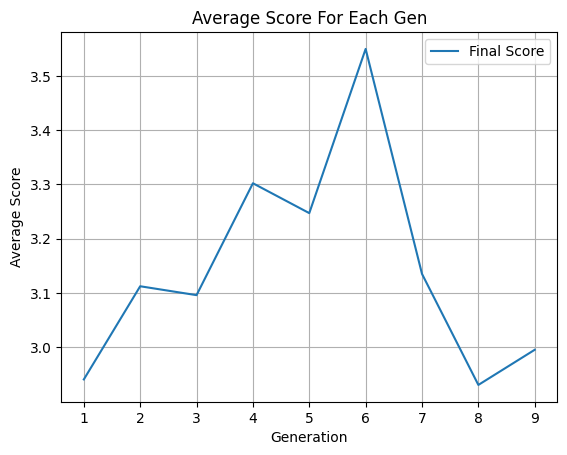

In [13]:
df[['Generation', 'Final Score']].groupby('Generation').mean().plot()
plt.ylabel('Average Score')
plt.title('Average Score For Each Gen')
plt.grid()
plt.show()

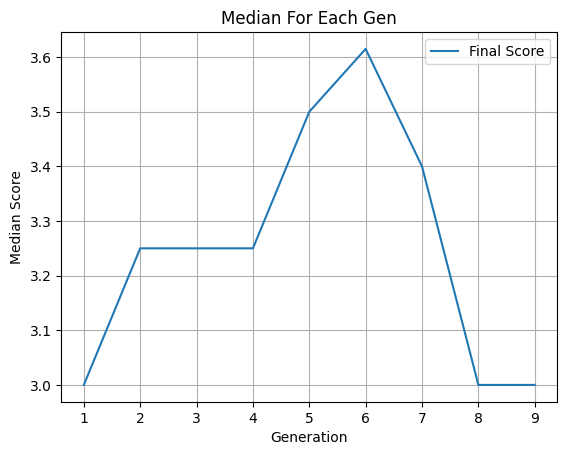

In [14]:
df[['Generation', 'Final Score']].groupby('Generation').median().plot()
plt.ylabel('Median Score')
plt.title('Median For Each Gen')
plt.grid()
plt.show()

Text(0, 0.5, 'Average Score')

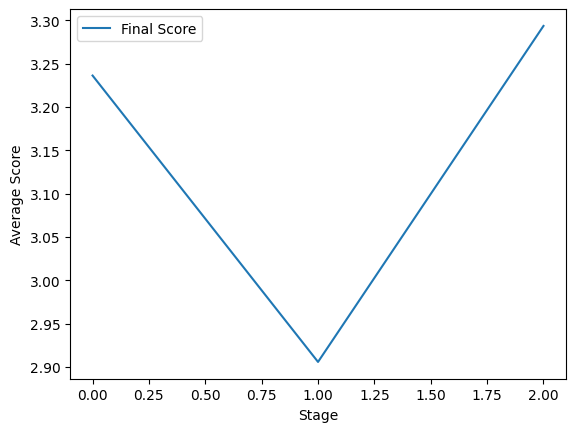

In [15]:
df[['Stage', 'Final Score']].groupby('Stage').mean().plot()
plt.ylabel('Average Score')

### Box Plot

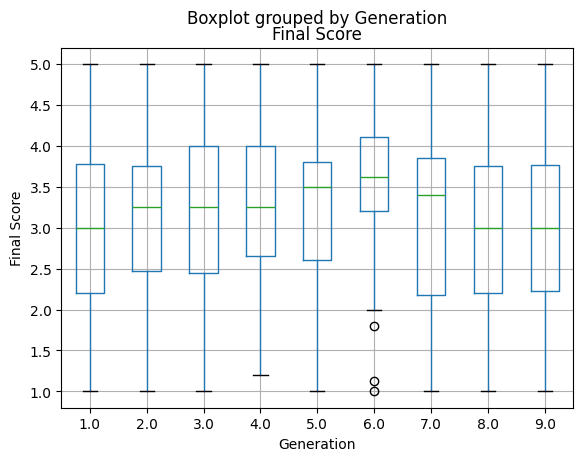

In [16]:

df.boxplot(column='Final Score', by='Generation')

plt.xlabel("Generation")
plt.ylabel("Final Score")
plt.show()

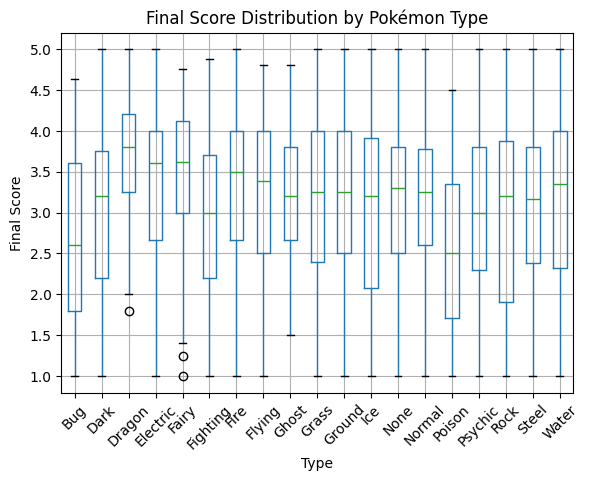

In [17]:
types = pd.concat([
    df[['Type1', 'Final Score']].rename(columns={'Type1': 'Type'}),
    df[['Type2', 'Final Score']].rename(columns={'Type2': 'Type'})
])

types.boxplot(column='Final Score', by='Type')

plt.xticks(rotation=45)
plt.xlabel("Type")
plt.ylabel("Final Score")
plt.title("Final Score Distribution by Pokémon Type")
plt.suptitle("") 

plt.show()

### Scatter Plot

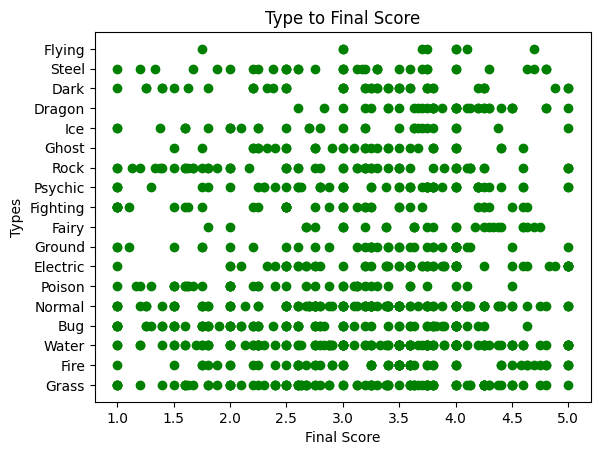

In [18]:
plt.scatter(df['Final Score'], df['Type1'], c='g')
plt.xlabel('Final Score')
plt.ylabel('Types')
plt.title('Type to Final Score')
plt.show()

### Bar Plot

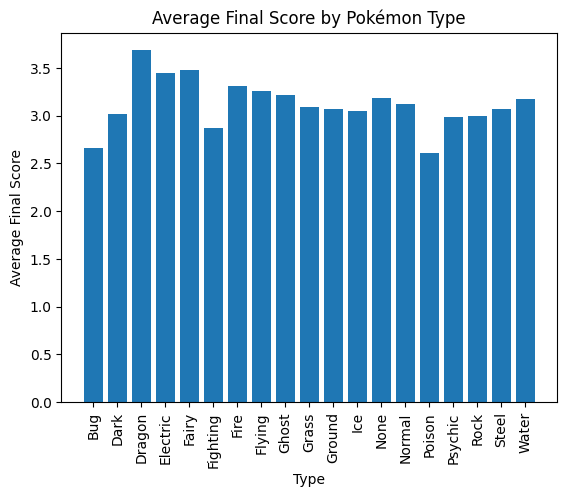

In [19]:
types = pd.concat([    
    df[['Type1', 'Final Score']].rename(columns={'Type1': 'Type'}),
    df[['Type2', 'Final Score']].rename(columns={'Type2': 'Type'})
])
data2 = types.groupby('Type')['Final Score'].mean()
plt.bar(data2.index, data2.values)
plt.xticks(rotation=90)
plt.xlabel("Type")
plt.ylabel("Average Final Score")
plt.title("Average Final Score by Pokémon Type")
plt.show()

In [20]:
type_count = pd.concat([df['Type1'], df['Type2']])
type_count.value_counts()

None        499
Water       154
Normal      131
Grass       127
Flying      109
Psychic     102
Bug          92
Poison       83
Fire         81
Ground       75
Rock         74
Fighting     73
Dragon       70
Electric     69
Dark         69
Ghost        65
Steel        65
Fairy        64
Ice          48
Name: count, dtype: int64

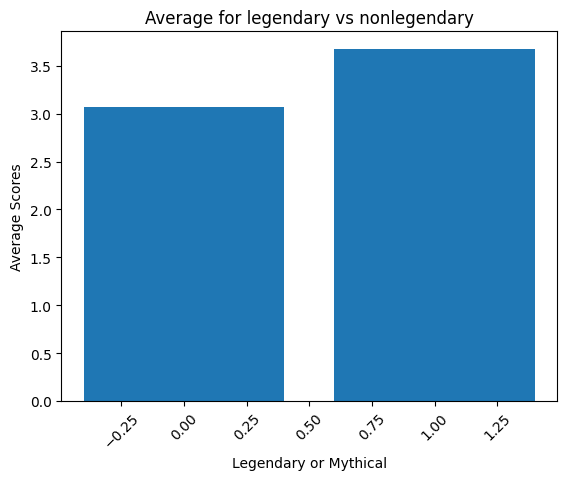

In [21]:
newdata = df[['Legendary/Mythical', 'Final Score']].groupby('Legendary/Mythical').mean()
plt.bar(newdata.index, newdata['Final Score'])
plt.xticks(rotation=45)
plt.xlabel('Legendary or Mythical')
plt.ylabel('Average Scores')
plt.title('Average for legendary vs nonlegendary')
plt.show()

Text(0.5, 1.0, 'Average for each stage')

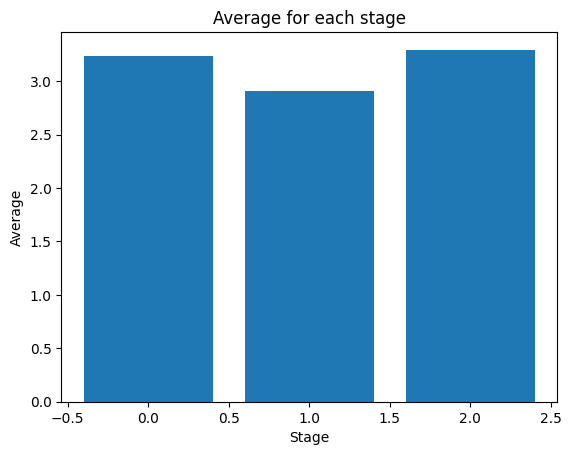

In [22]:
stagedata = df[['Stage', 'Final Score']].groupby('Stage').mean()
plt.bar(stagedata.index, stagedata['Final Score'])
plt.xlabel('Stage')
plt.ylabel('Average')
plt.title('Average for each stage')

Text(0.5, 1.0, 'Average Score For Each Gen')

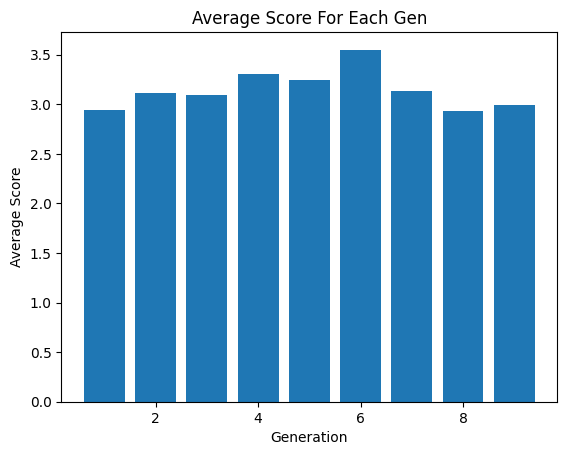

In [23]:
gendata = df[['Generation', 'Final Score']].groupby('Generation').mean()
plt.bar(gendata.index, gendata['Final Score'])
plt.xlabel('Generation')
plt.ylabel('Average Score')
plt.title('Average Score For Each Gen')

### Histogram

Text(0.5, 1.0, 'Count for each Final Score')

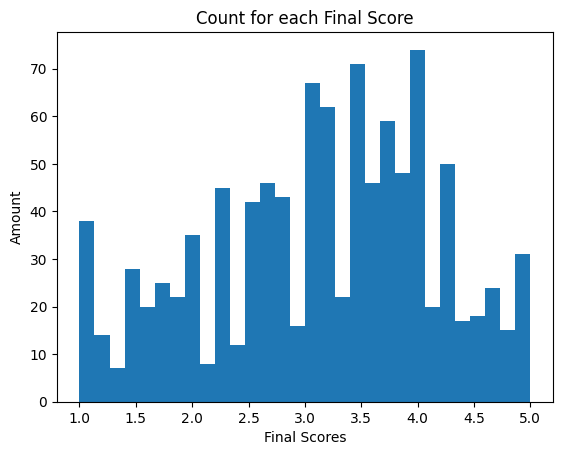

In [24]:
plt.hist(df['Final Score'], bins=30)
plt.xlabel('Final Scores')
plt.ylabel('Amount')
plt.title('Count for each Final Score')

In [25]:
df['Final Score'].std()

np.float64(1.0136571787111972)

## Stats Practice

In [26]:
# look at z scores
stats.zscore(df['Final Score'])

array([ 1.35476293,  1.15736125, -0.71795473, ..., -0.12574969,
        0.53554595, -1.1127581 ], shape=(1025,))

t-statistic: -4.7740977079473135
p-value: 3.715057951321174e-06


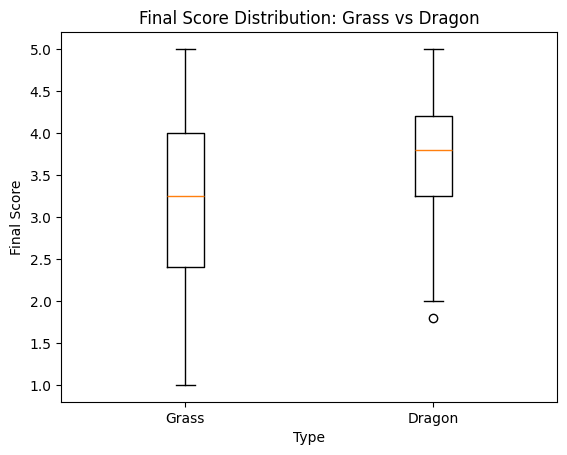

In [38]:
# do t test on different types
first_type = types.loc[types['Type'] == 'Grass', 'Final Score']
second_type = types.loc[types['Type'] == 'Dragon', 'Final Score']

t_stat, p_value = stats.ttest_ind(first_type, second_type, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_value)

# plot it
plt.boxplot([first_type, second_type], tick_labels=['Grass', 'Dragon'])
plt.xlabel("Type")
plt.ylabel("Final Score")
plt.title("Final Score Distribution: Grass vs Dragon")
plt.show()

In [29]:
# do Mann-Whitney U test on different types
u_stat, p_value1 = stats.mannwhitneyu(first_type, second_type, alternative='two-sided')
print("u-statistic:", u_stat)
print("p-value:", p_value1)

u-statistic: 2939.5
p-value: 8.405137240655644e-05


t-statistic: -0.4141419688242717
p-value: 0.679100163617778


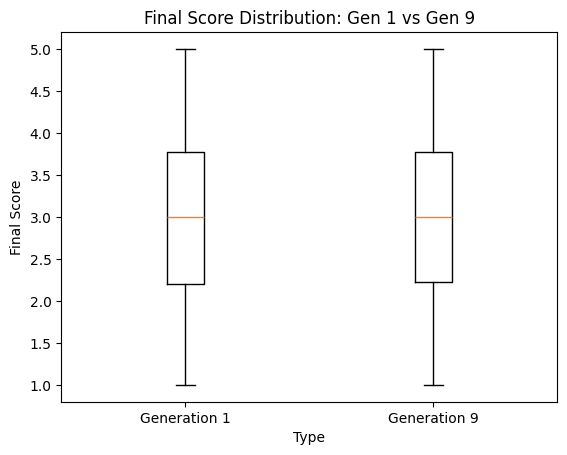

In [39]:
# do t test on different generations
gen1 = df.loc[df['Generation'] == 1, 'Final Score']
gen2 = df.loc[df['Generation'] == 9, 'Final Score']

t_stat1, p_value2 = stats.ttest_ind(gen1, gen2)

print("t-statistic:", t_stat1)
print("p-value:", p_value2)

# plot it
plt.boxplot([gen1, gen2], tick_labels=['Generation 1', 'Generation 9'])
plt.xlabel("Type")
plt.ylabel("Final Score")
plt.title("Final Score Distribution: Gen 1 vs Gen 9")
plt.show()

In [31]:
# do t test on legendary/mythical
legendary = df.loc[df['Legendary/Mythical'] == 1, 'Final Score']
non_legendary = df.loc[df['Legendary/Mythical'] == 0, 'Final Score']

t_stat2, p_value3 = stats.ttest_ind(legendary, non_legendary)

print("t-statistic:", t_stat2)
print("p-value:", p_value3)

t-statistic: 5.951162348314132
p-value: 3.6535422732295126e-09


In [32]:
# do anova test on all types
Water = types.loc[types['Type'] == 'Water', 'Final Score']
Normal = types.loc[types['Type'] == 'Normal', 'Final Score']
Grass = types.loc[types['Type'] == 'Grass', 'Final Score']
Flying = types.loc[types['Type'] == 'Flying', 'Final Score']
Psychic = types.loc[types['Type'] == 'Psychic', 'Final Score']
Bug = types.loc[types['Type'] == 'Bug', 'Final Score']
Poison = types.loc[types['Type'] == 'Poison', 'Final Score']
Fire = types.loc[types['Type'] == 'Fire', 'Final Score']
Ground = types.loc[types['Type'] == 'Ground', 'Final Score']
Rock = types.loc[types['Type'] == 'Rock', 'Final Score']
Fighting = types.loc[types['Type'] == 'Fighting', 'Final Score']
Dragon = types.loc[types['Type'] == 'Dragon', 'Final Score']
Electric = types.loc[types['Type'] == 'Electric', 'Final Score']
Dark = types.loc[types['Type'] == 'Dark', 'Final Score']
Ghost = types.loc[types['Type'] == 'Ghost', 'Final Score']
Steel = types.loc[types['Type'] == 'Steel', 'Final Score']
Fairy = types.loc[types['Type'] == 'Fairy', 'Final Score']
Ice = types.loc[types['Type'] == 'Ice', 'Final Score']

f_stat, p_val = stats.f_oneway(Water, Normal, Grass, Flying, Psychic, Bug, Poison, Fire, Ground, Rock, Fighting, Dragon, Electric, Dark, Ghost, Steel, Fairy, Ice)

print("f-statistic:", f_stat)
print("p-value:", p_val)

# plot it 

f-statistic: 5.578505915565679
p-value: 2.1693821916129717e-12


In [33]:
# do tukey test on all types
tukey2 = pairwise_tukeyhsd(endog=types['Final Score'], groups=types['Type'], alpha=0.05)
print(tukey2)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1   group2  meandiff p-adj   lower   upper  reject
--------------------------------------------------------
     Bug     Dark   0.3533 0.7578 -0.2044   0.911  False
     Bug   Dragon   1.0212    0.0  0.4658  1.5766   True
     Bug Electric   0.7823 0.0001  0.2246    1.34   True
     Bug    Fairy   0.8144 0.0001  0.2444  1.3844   True
     Bug Fighting   0.2038 0.9987  -0.345  0.7527  False
     Bug     Fire   0.6486 0.0029   0.115  1.1821   True
     Bug   Flying   0.5932 0.0038  0.0974   1.089   True
     Bug    Ghost   0.5551 0.0638 -0.0124  1.1225  False
     Bug    Grass   0.4249 0.1606 -0.0545  0.9043  False
     Bug   Ground   0.4098  0.443  -0.135  0.9545  False
     Bug      Ice   0.3875 0.7855  -0.236   1.011  False
     Bug     None   0.5174 0.0007  0.1201  0.9148   True
     Bug   Normal   0.4545 0.0826 -0.0219  0.9308  False
     Bug   Poison  -0.0588    1.0 -0.5889  0.4714  False
     Bug  Psychic   0.3197 0.75

In [34]:
# do anova test on all gens
gen_1 = df.loc[df['Generation'] == 1, 'Final Score']
gen_2 = df.loc[df['Generation'] == 2, 'Final Score']
gen3 = df.loc[df['Generation'] == 3, 'Final Score']
gen4 = df.loc[df['Generation'] == 4, 'Final Score']
gen5 = df.loc[df['Generation'] == 5, 'Final Score']
gen6 = df.loc[df['Generation'] == 6, 'Final Score']
gen7 = df.loc[df['Generation'] == 7, 'Final Score']
gen8 = df.loc[df['Generation'] == 8, 'Final Score']
gen9 = df.loc[df['Generation'] == 9, 'Final Score']

f_stat1, p_val1 = stats.f_oneway(gen_1, gen_2, gen3, gen4, gen5, gen6, gen7, gen8, gen9)

print("f-statistic:", f_stat1)
print("p-value:", p_val1)

f-statistic: 3.6678715976268492
p-value: 0.0003155162831038226


In [35]:
# do tukey test for all gens 
tukey = pairwise_tukeyhsd(endog=df['Final Score'], groups=df['Generation'], alpha=0.05)
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   1.0    2.0   0.1715 0.9235 -0.2305  0.5736  False
   1.0    3.0   0.1552 0.9298 -0.2142  0.5246  False
   1.0    4.0   0.3612 0.1028 -0.0329  0.7553  False
   1.0    5.0   0.3062 0.1587 -0.0498  0.6622  False
   1.0    6.0   0.6085 0.0008  0.1619  1.0552   True
   1.0    7.0   0.1943 0.8805  -0.224  0.6125  False
   1.0    8.0  -0.0101    1.0 -0.4172   0.397  False
   1.0    9.0   0.0546    1.0 -0.3268   0.436  False
   2.0    3.0  -0.0164    1.0 -0.4278  0.3951  False
   2.0    4.0   0.1896 0.9127 -0.2441  0.6234  False
   2.0    5.0   0.1346  0.981 -0.2649  0.5341  False
   2.0    6.0    0.437 0.1113  -0.045   0.919  False
   2.0    7.0   0.0227    1.0 -0.4331  0.4786  False
   2.0    8.0  -0.1817 0.9405 -0.6273  0.2639  False
   2.0    9.0  -0.1169 0.9948 -0.5392  0.3053  False
   3.0    4.0    0.206 0.8123 -0.1976  0.6097 

In [36]:
# do anova test on each stage
basic = df.loc[df['Stage'] == 0, 'Final Score']
stage1 = df.loc[df['Stage'] == 1, 'Final Score']
stage2 = df.loc[df['Stage'] == 2, 'Final Score']

f_stat2, p_val2 = stats.f_oneway(basic, stage1, stage2)

print("f-statistic:", f_stat2)
print("p-value:", p_val2)

f-statistic: 13.643005873430791
p-value: 1.4211287409174444e-06


In [37]:
# do tukey test on each stage
tukey1 = pairwise_tukeyhsd(endog=df['Final Score'], groups=df['Stage'], alpha=0.05)
print(tukey1)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   0.0    1.0  -0.3306    0.0 -0.4902 -0.1709   True
   0.0    2.0   0.0573 0.8393 -0.1812  0.2958  False
   1.0    2.0   0.3879 0.0008  0.1384  0.6374   True
----------------------------------------------------
